<a href="https://colab.research.google.com/github/almahmud23/Link-of-Drive/blob/Mahmud/Lab_Report_2_212002142.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
file_path = '/content/Data_Cleaning_Dataset.csv'
df = pd.read_csv(file_path)

In [3]:
print(df.head())

  EmployeeID EmployeeName   Age Department   JoiningDate     Salary
0    EID1001   Employee_1  19.0    Finance    2021-03-07    4901.91
1    EID1002   Employee_2  33.0    Finance    2023-10-09  200000.00
2    EID1003   Employee_3  65.0         HR    2022-02-07    4949.93
3    EID1004   Employee_4  65.0  Marketing    2022-04-25    7178.64
4    EID1005   Employee_5  23.0      Sales  "2020-07-08"    6673.17


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   EmployeeID    160 non-null    object 
 1   EmployeeName  160 non-null    object 
 2   Age           146 non-null    float64
 3   Department    160 non-null    object 
 4   JoiningDate   160 non-null    object 
 5   Salary        145 non-null    float64
dtypes: float64(2), object(4)
memory usage: 7.6+ KB
None


In [5]:
print("\nMissing Values Count:")
print(df.isnull().sum())


Missing Values Count:
EmployeeID       0
EmployeeName     0
Age             14
Department       0
JoiningDate      0
Salary          15
dtype: int64


In [8]:
print("\n Fill missing values(Use mean-for numeric type & mode-for objects type). ")
df_filled = df.copy()
for col in df_filled.columns:
    if df_filled[col].dtype == 'object':
        df_filled[col] = df_filled[col].fillna(df_filled[col].mode()[0])
    else:
        df_filled[col] = df_filled[col].fillna(df_filled[col].mean())


 Fill missing values(Use mean-for numeric type & mode-for objects type). 


In [10]:
print("\n Check Missing Values Now:")
print(df_filled.isnull().sum())


 Check Missing Values Now:
EmployeeID      0
EmployeeName    0
Age             0
Department      0
JoiningDate     0
Salary          0
dtype: int64



Visualizations


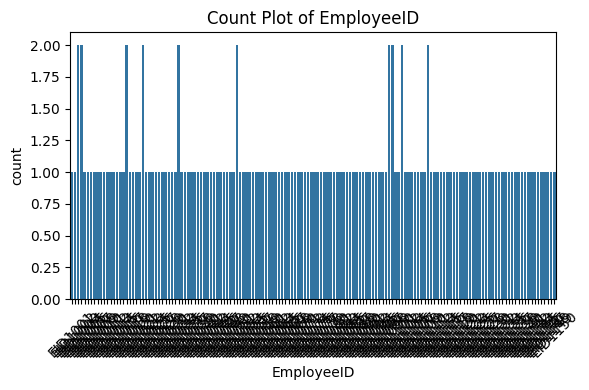

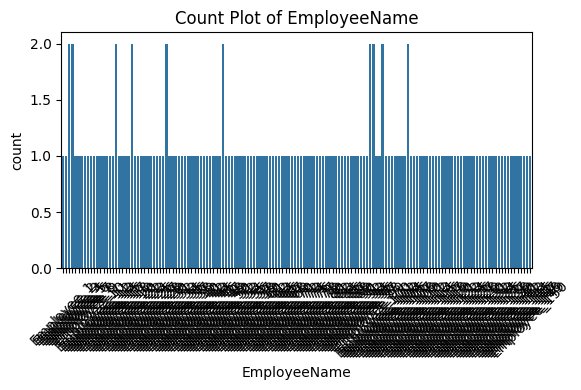

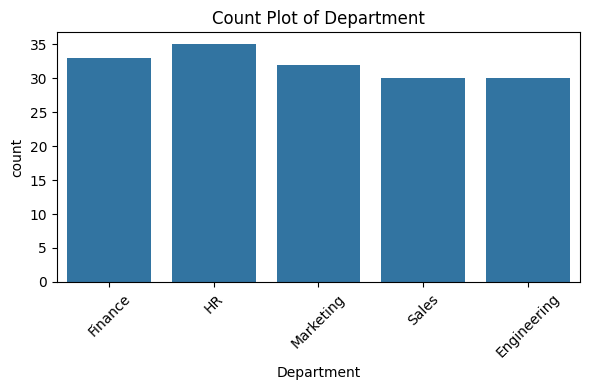

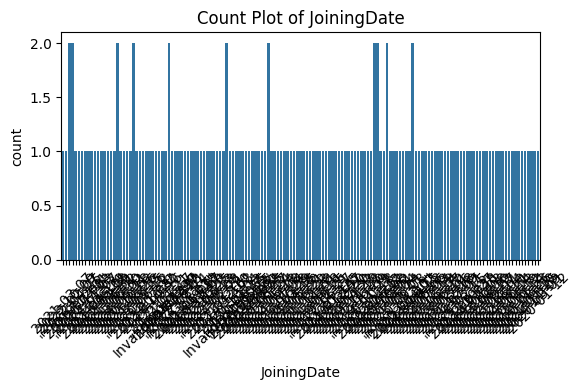

In [26]:
print("\nVisualizations Objets Type column: ")

categorical_cols = df_filled.select_dtypes(include='object').columns
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_filled, x=col)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Visualizations Objets Type column: 


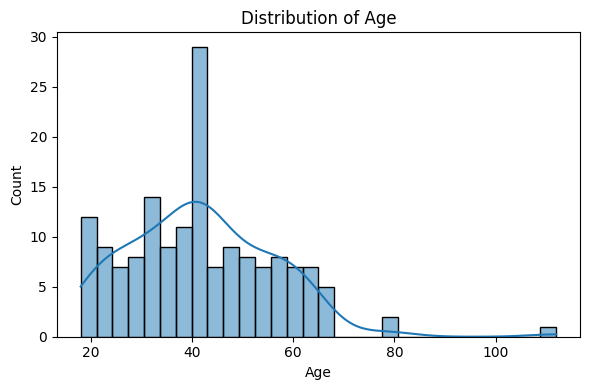

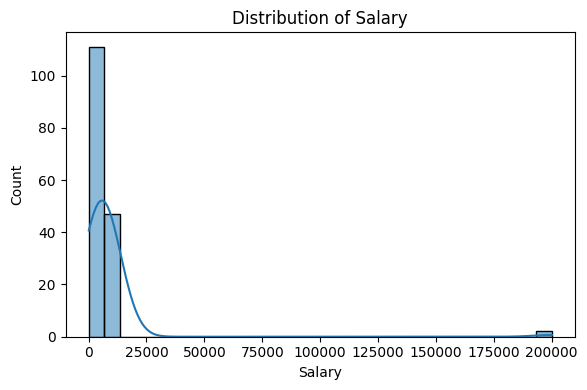

In [27]:
print("\nVisualizations Objets Type column: ")

numeric_cols = df_filled.select_dtypes(include=np.number).columns
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_filled[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()


Heatmap of Correlation:


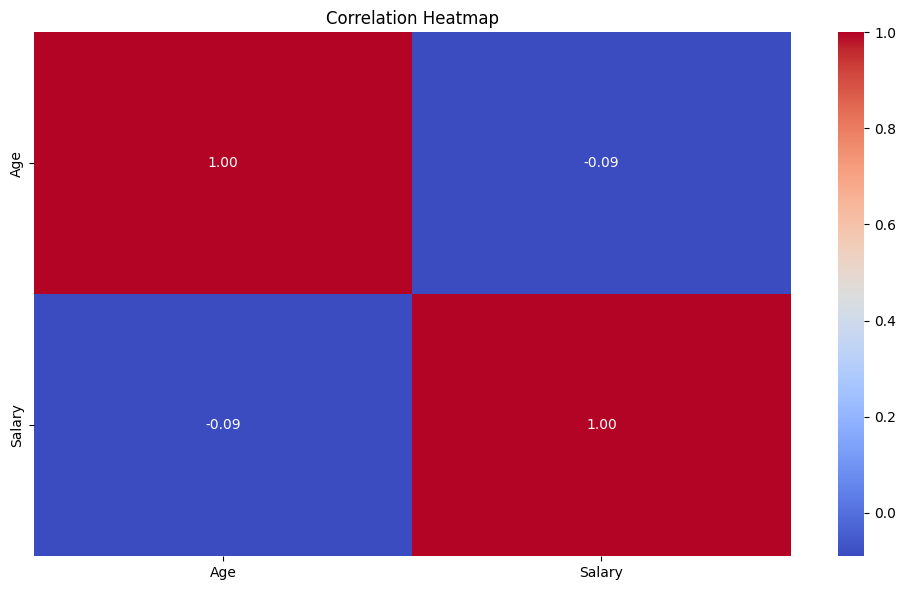

In [28]:
print("\nHeatmap of Correlation:")

plt.figure(figsize=(10, 6))
correlation = df_filled[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [21]:
df_encoded = pd.get_dummies(df_filled)
print("\nEncoded Data:")
print(df_encoded.head())


Encoded Data:
    Age     Salary  EmployeeID_EID1001  EmployeeID_EID1002  \
0  19.0    4901.91                True               False   
1  33.0  200000.00               False                True   
2  65.0    4949.93               False               False   
3  65.0    7178.64               False               False   
4  23.0    6673.17               False               False   

   EmployeeID_EID1003  EmployeeID_EID1004  EmployeeID_EID1005  \
0               False               False               False   
1               False               False               False   
2                True               False               False   
3               False                True               False   
4               False               False                True   

   EmployeeID_EID1006  EmployeeID_EID1007  EmployeeID_EID1008  ...  \
0               False               False               False  ...   
1               False               False               False  ...   
2          

In [23]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)
print("\nScaled Data:")
print(scaled_data)


Scaled Data:
[[-1.56643863 -0.15196948 12.60952021 ... -0.07930516 -0.07930516
  -0.11250879]
 [-0.6058024   8.86156861 -0.07930516 ... -0.07930516 -0.07930516
  -0.11250879]
 [ 1.58993756 -0.14975095 -0.07930516 ... -0.07930516 -0.07930516
  -0.11250879]
 ...
 [-1.42920489 -0.14163084 -0.07930516 ... -0.07930516 -0.07930516
  -0.11250879]
 [ 1.10961945 -0.09638021 -0.07930516 ... -0.07930516 -0.07930516
  -0.11250879]
 [-1.36058801 -0.06887687 -0.07930516 ... -0.07930516 -0.07930516
  -0.11250879]]


In [24]:
df_scaled = pd.DataFrame(scaled_data, columns=df_encoded.columns)

print("\n After Polish Scaled Data Sample:")
print(df_scaled.head())


 After Polish Scaled Data Sample:
        Age    Salary  EmployeeID_EID1001  EmployeeID_EID1002  \
0 -1.566439 -0.151969           12.609520           -0.079305   
1 -0.605802  8.861569           -0.079305           12.609520   
2  1.589938 -0.149751           -0.079305           -0.079305   
3  1.589938 -0.046784           -0.079305           -0.079305   
4 -1.291971 -0.070137           -0.079305           -0.079305   

   EmployeeID_EID1003  EmployeeID_EID1004  EmployeeID_EID1005  \
0           -0.112509           -0.112509           -0.079305   
1           -0.112509           -0.112509           -0.079305   
2            8.888194           -0.112509           -0.079305   
3           -0.112509            8.888194           -0.079305   
4           -0.112509           -0.112509           12.609520   

   EmployeeID_EID1006  EmployeeID_EID1007  EmployeeID_EID1008  ...  \
0           -0.079305           -0.079305           -0.079305  ...   
1           -0.079305           -0.079305  